# UT4 - Sesión 4: Introducción a OpenCV
**Módulo:** Programación de Inteligencia Artificial y Big Data  
**Unidad:** UT4 - Tratamiento de Imagen

---

### Objetivo de la práctica
Dejar de tratar las imágenes "a mano" con bucles de NumPy y empezar a usar las herramientas profesionales de **OpenCV (cv2)**.  
Aprenderás a gestionar archivos, transformar geometría, dibujar y, lo más importante, **entender la lógica de las máscaras binarias**.

### Requisitos previos
Necesitas una imagen llamada `imagen_a_analizar.png` en la misma carpeta que este notebook. Puedes usar cualquier foto (preferiblemente una con colores vivos y objetos definidos).

In [1]:
# 🛠️ CONFIGURACIÓN INICIAL
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuración para que las imágenes se vean bien en el notebook
import matplotlib
matplotlib.rcParams['figure.figsize'] = (6.0, 6.0)
matplotlib.rcParams['image.cmap'] = 'gray'

print(f"Versión de OpenCV instalada: {cv2.__version__}")

imagen_de_carga = 'images/caramelos.jpg'

Versión de OpenCV instalada: 4.13.0


---

## NIVEL 1: Primeros Pasos (Guiado)
*Objetivo: Familiarizarse con la sintaxis básica y el problema BGR vs RGB.*

### Ejercicio 1: Carga y Visualización
Carga la imagen `imagen_a_analizar.png`. Recuerda que OpenCV carga en **BGR** (Azul-Verde-Rojo), pero Matplotlib espera **RGB**. Si no conviertes, los colores saldrán invertidos.

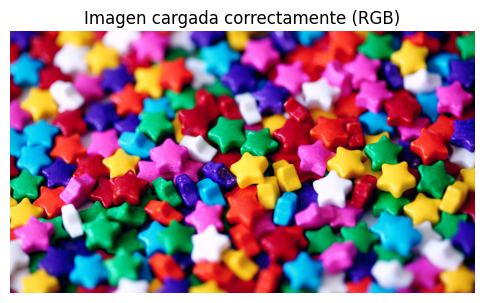

In [2]:
# 1. Cargar imagen
img_bgr = cv2.imread(imagen_de_carga)

# 2. Comprobar seguridad
if img_bgr is None:
    print("Error: No se encuentra la imagen. Sube una foto a la carpeta.")
else:
    # 3. Convertir de BGR a RGB para visualizar en el notebook
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 4. Mostrar
    plt.imshow(img_rgb)
    plt.title("Imagen cargada correctamente (RGB)")
    plt.axis('off')
    plt.show()

### Ejercicio 2: Inspección de Propiedades
Las imágenes en OpenCV siguen siendo arrays de NumPy. Es vital saber cuánto miden.

In [3]:
if img_bgr is not None:
    # .shape devuelve (Alto, Ancho, Canales)
    alto, ancho, canales = img_bgr.shape

    print(f"🔹 Altura: {alto} píxeles")
    print(f"🔹 Anchura: {ancho} píxeles")
    print(f"🔹 Canales: {canales} (3 = Color, 1 = Gris)")
    print(f"🔹 Tipo de dato: {img_bgr.dtype}") # uint8 es el estándar (0-255)

🔹 Altura: 2160 píxeles
🔹 Anchura: 3840 píxeles
🔹 Canales: 3 (3 = Color, 1 = Gris)
🔹 Tipo de dato: uint8


### Ejercicio 3: Guardar Archivos
Vamos a convertir la imagen a escala de grises y guardarla en el disco duro como un archivo PNG nuevo.

In [4]:
# 1. Convertir a Grises
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 2. Guardar en disco
# cv2.imwrite('nombre_archivo', variable_imagen)
exito = cv2.imwrite('resultado_gris.png', img_gray)

if exito:
    print("Imagen guardada como 'resultado_gris.png'. Revisa tu carpeta.")
else:
    print("Error al guardar.")

Imagen guardada como 'resultado_gris.png'. Revisa tu carpeta.


### Ejercicio 4: Recorte (ROI - Region of Interest)
OpenCV no tiene una función `.crop()`. Utilizamos directamente el **Slicing de NumPy**.
La sintaxis es `imagen[y_inicio:y_fin, x_inicio:x_fin]`.

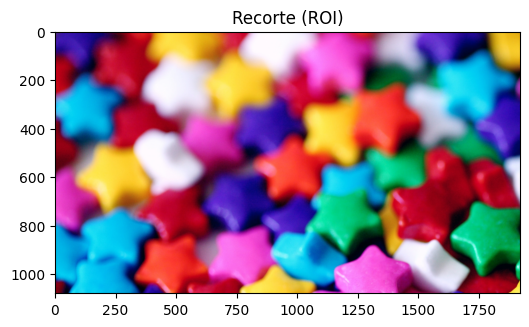

In [5]:
# Recortamos el cuadrante superior izquierdo
mitad_alto = alto // 2
mitad_ancho = ancho // 2

# OJO: Primero va el eje Y (filas), luego el X (columnas)
recorte = img_rgb[0:mitad_alto, 0:mitad_ancho]

plt.imshow(recorte)
plt.title("Recorte (ROI)")
plt.show()

### Ejercicio 5: Separación de Canales (Split)
Podemos separar la imagen en sus tres capas (Blue, Green, Red) para procesarlas individualmente.

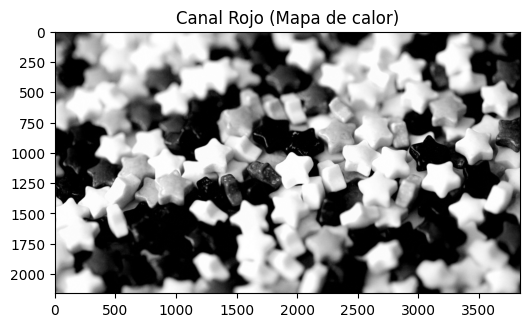

In [6]:
B, G, R = cv2.split(img_bgr)

# Visualizamos el canal ROJO
# Nota: Se ve en blanco y negro. Las zonas blancas son las que tienen mucho rojo.
plt.imshow(R, cmap='gray')
plt.title("Canal Rojo (Mapa de calor)")
plt.show()

---

## NIVEL 2: Manipulación (Intermedio)
*Instrucciones: En estos ejercicios sabes el objetivo, pero debes encontrar la función adecuada en la librería `cv2`. Presta mucha atención al orden de los parámetros, es donde suelen fallar estos algoritmos.*

### Ejercicio 6: Redimensionado
Queremos reducir la imagen a la mitad.
**Reto:** OpenCV es muy estricto con el tipo de dato de las dimensiones (deben ser enteros) y con el orden (primero ancho, luego alto).

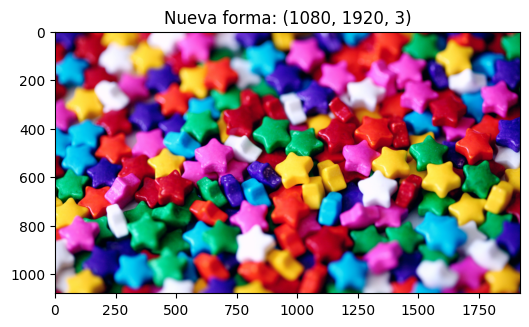

In [7]:
# 1. Calcular las nuevas dimensiones
# OJO: Las dimensiones en píxeles deben ser números enteros (int), no decimales.
nuevo_ancho = int(ancho / 2)
nuevo_alto = int(alto / 2)
nuevas_dims = (nuevo_ancho, nuevo_alto)

# 2. Busca la función de OpenCV para cambiar el tamaño (Resize)
# Pista: La función pide (imagen_origen, tamaño_destino_tupla)
# img_pequena = cv2.______(______, ______) 
img_pequena = cv2.resize(img_rgb, nuevas_dims)

plt.imshow(img_pequena)
plt.title(f"Nueva forma: {img_pequena.shape}")
plt.show()

### Ejercicio 7: Rotación (La matriz de transformación)
En OpenCV, rotar no es una sola función. Es un proceso de dos pasos:
1. Calcular la matemática (Matriz de 2x3).
2. Aplicar esa matriz a los píxeles (Transformación Afín).

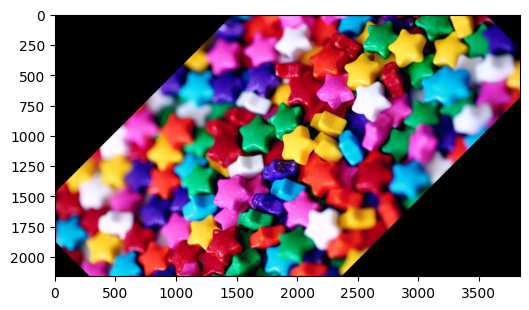

In [8]:
centro = (ancho // 2, alto // 2)
angulo = 45
escala = 1.0

# 1. Generar la Matriz de Rotación
# Busca una función que devuelva una "RotationMatrix2D"
M = cv2.getRotationMatrix2D(centro, angulo, escala)

# 2. Aplicar la transformación
# Busca una función que aplique una transformación afín ("Warp Affine")
# Nota: Esta función pide el tamaño final como (ancho, alto)
img_rotada = cv2.warpAffine(img_rgb, M, (ancho, alto))

plt.imshow(img_rotada)
plt.show()

### Ejercicio 8: Dibujar Formas Geométricas
Dibuja un rectángulo verde y un círculo azul sólido.
**Reto:** Busca en la documentación cómo indicar que un círculo debe estar **relleno** en lugar de solo dibujar el borde.

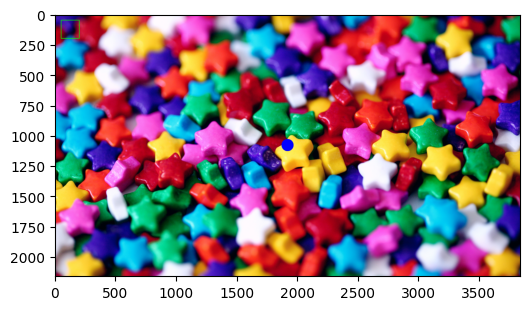

In [9]:
img_dibujo = img_rgb.copy()

# 1. Rectángulo Verde
# Busca la función que dibuja un rectángulo. Parámetros típicos: img, pt1, pt2, color, grosor.
# Dibuja desde (50,50) hasta (200,200). Color Verde en RGB es (0, 255, 0).
cv2.rectangle(img_dibujo, (50, 50), (200, 200), (0, 255, 0), 3)

# 2. Círculo Azul Relleno
# Busca la función que dibuja un círculo.
# Pista: Para rellenar una figura cerrada, el grosor (thickness) debe ser un número negativo específico.
cv2.circle(img_dibujo, (ancho//2, alto//2), 50, (0, 0, 255), -1)

plt.imshow(img_dibujo)
plt.show()

### Ejercicio 9: Umbralización (Binarizar)
Convierte la imagen a blanco y negro puro. Los píxeles claros serán blancos, los oscuros negros.
**Reto:** La función de umbral devuelve **dos** valores (una tupla). El primero es el umbral usado, el segundo es la imagen. Debes capturar solo la imagen.

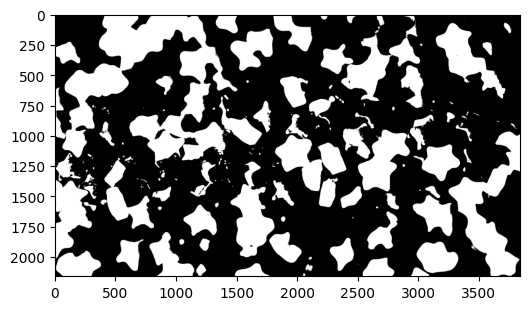

In [10]:
# Convertimos a grises primero
gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Aplicar Umbral fijo (Threshold)
# Busca la función que aplica un umbral.
# Parámetros: imagen, valor_umbral(127), valor_maximo(255), tipo_umbral(BINARY)
# ¡Cuidado con el desempaquetado de la tupla de retorno!
_, binaria = cv2.threshold(gris, 127, 255, cv2.THRESH_BINARY)

plt.imshow(binaria, cmap='gray')
plt.show()

### Ejercicio 10: Máscaras (La lógica de bits)
Tienes una máscara blanca sobre fondo negro. Quieres usarla para recortar la imagen original.
**Reto:** Entender que esto es una operación lógica `AND`. Si `A=Imagen` y `B=Mascara`: ¿Cómo hacemos para que solo quede `A` donde `B` es verdadero?

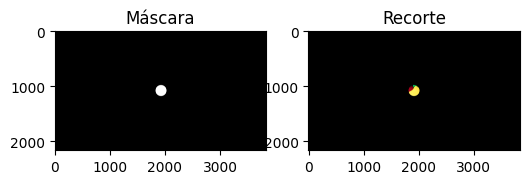

In [11]:
# Preparamos una máscara de ejemplo (Círculo blanco)
mascara = np.zeros((alto, ancho), dtype='uint8')
cv2.circle(mascara, (ancho//2, alto//2), 100, 255, -1)

# Aplicar la máscara
# Busca una función para la operación lógica "Bitwise AND".
# Truco: Estas funciones suelen pedir dos imágenes (src1, src2).
# Como solo tenemos una imagen real, pon la misma imagen en src1 y src2.
# Pasa la variable 'mascara' en el parámetro con nombre 'mask'.
resultado = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara)

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(mascara, cmap='gray'); ax1.set_title("Máscara")
ax2.imshow(resultado); ax2.set_title("Recorte")
plt.show()

---

## NIVEL 3: Retos de Investigación (Sin pistas)
*Instrucciones: A partir de aquí se acabó la ayuda guiada. Tienes el enunciado del problema y una celda vacía. Deberás buscar en Google o en la documentación oficial las funciones necesarias para resolverlo. ¡Bienvenido al trabajo real de un ingeniero de Visión Artificial!*

### Ejercicio 11: Detector de Objetos Rojos (El problema del Matiz)
Crea un script que genere una máscara que muestre **SOLO** los píxeles rojos de la imagen.

**El Reto:** Si intentas detectar el rojo como cualquier otro color, verás que fallas o te dejas la mitad fuera. 
**Investiga:** ¿Qué pasa con el matiz (Hue) del color ROJO en el círculo cromático de OpenCV (0-179)? ¿Está todo junto o separado? Tu código debe manejar esta excepción para ser robusto.

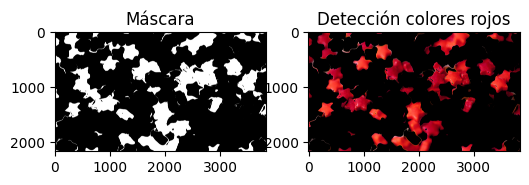

In [12]:
# 1. Convertir a HSV
imagen_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
# 2. Gestionar el rango del rojo (Investiga: ¿es un solo rango o son dos?)
# Máscara 1
lower_red = np.array([0,50,50])
upper_red = np.array([10,255,255])
mask1 = cv2.inRange(imagen_hsv, lower_red, upper_red)
# Máscara 2
lower_red = np.array([170,50,50])
upper_red = np.array([180,255,255])
mask2 = cv2.inRange(imagen_hsv, lower_red, upper_red)

# 3. Generar la máscara final
mask = mask1 + mask2
# 4. Visualizar resultado (bitwise)
img_result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(mask, cmap='gray'); ax1.set_title("Máscara")
ax2.imshow(img_result); ax2.set_title("Detección colores rojos")
plt.show()

### Ejercicio 12: Efecto Espejo Panorámico
Genera una nueva imagen que sea el doble de ancha que la original. En la mitad izquierda debe estar la imagen original y en la mitad derecha su reflejo en espejo (flip horizontal).

**Investiga:** 
1. Cómo voltear una matriz (Flip).
2. Cómo concatenar dos matrices horizontalmente (Stacking).

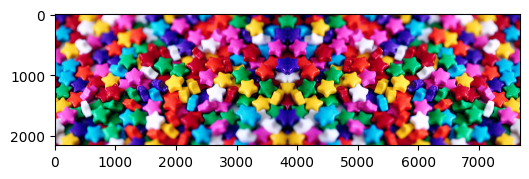

In [13]:
img_rgb_flip = cv2.flip(img_rgb, 1)
img_panoramica = np.hstack((img_rgb, img_rgb_flip))
plt.imshow(img_panoramica, cmap= "gray")
plt.show()

### Ejercicio 13: Texto Perfectamente Centrado
Escribe la palabra "INTELIGENCIA ARTIFICIAL" en el **centro geométrico exacto** de la imagen.

**El problema:** `cv2.putText` usa coordenadas, pero no sabe centrar texto automáticamente. Si pones el punto `(ancho/2, alto/2)`, el texto empezará ahí y quedará desplazado a la derecha.
**Reto:** Busca una función que te permita **medir** cuántos píxeles de ancho y alto ocupará una frase con una fuente y escala concretas ANTES de pintarla, para poder calcular la posición de inicio correcta.

Tamaño de la frase: ((2964, 178), 82)


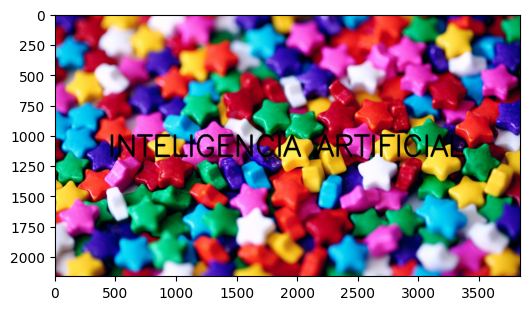

In [14]:
tamano_frase = cv2.getTextSize("INTELIGENCIA ARTIFICIAL", cv2.FONT_HERSHEY_SIMPLEX, 8, 20)
print("Tamaño de la frase:", tamano_frase)
img_text = cv2.putText(img_rgb, "INTELIGENCIA ARTIFICIAL", (ancho//2 - tamano_frase[0][0]//2, alto//2 + tamano_frase[0][1]//2), cv2.FONT_HERSHEY_SIMPLEX, 8, (0, 0, 0), 20)
plt.imshow(img_text, cmap= "gray")
plt.show()

### Ejercicio 14: Controlador de Brillo Interactivo
**Advertencia:** Usa `cv2.imshow` y `cv2.waitKey` (ventana nativa).

Crea una aplicación con un **Trackbar** que vaya de 0 a 100. Al moverlo, la imagen debe volverse más brillante.

**El Reto Matemático:** Si simplemente sumas el valor del trackbar a la imagen (`img + valor`), verás que al subir mucho el brillo ocurren cosas extrañas (colores que se invierten o ruido). 
**Investiga:** ¿Qué es la **Saturación** en las operaciones aritméticas de OpenCV y qué función debes usar para sumar sin que el valor 255 "dé la vuelta" a 0?

In [18]:
import cv2
import numpy as np
img_brillo = img_rgb.copy()
# Estructura recomendada:
# 1. Definir función callback vacía
def nada(x):
    pass
# 2. Crear ventana y trackbar
cv2.namedWindow("Controlador de brillo interactivo", cv2.WINDOW_NORMAL)
cv2.createTrackbar("Brillo", "Controlador de brillo interactivo", 0, 100, nada)
matriz_brillo = np.ones_like(img_brillo)
# 3. Bucle infinito:
while True:
    #    - Comprobar seguridad ventana (getWindowProperty)
    cv2.getWindowProperty("Controlador de brillo interactivo", cv2.WND_PROP_VISIBLE)
    #    - Leer trackbar
    brillo = cv2.getTrackbarPos("Brillo", "Controlador de brillo interactivo")
    #    - Operar imagen (Cuidado con el tipo de suma)
    #img_brillo = cv2.convertScaleAbs(img_brillo, alpha = 1, beta = brillo)
    matriz_brillo = matriz_brillo * brillo
    img_brillo = cv2.add(img_brillo, brillo)
    #    - Mostrar
    cv2.imshow("Controlador de brillo interactivo", img_brillo)
    #    - Salir con 'q'
    key = cv2.waitKey(0) & 0xFF
    if key == ord("q"):
        cv2.destroyAllWindows()
        break

### Ejercicio 15: Color Selectivo (Efecto "Sin City" o "Schindler's List")
**El Boss Final.** 
Consigue el siguiente efecto artístico: **Toda la imagen debe estar en blanco y negro, EXCEPTO un objeto de un color concreto (ej: rojo), que debe mantenerse en color original.**

No te daré pasos. Solo el objetivo. Tendrás que diseñar tú el algoritmo combinando máscaras, inversiones lógicas y sumas de imágenes.

In [16]:
# TU CÓDIGO AQUÍ